In [1]:
# 1. IMPORTS
# ==============================
from dotenv import load_dotenv, find_dotenv
from typing import TypedDict, Annotated
import math

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool

import time
from ddgs import DDGS
import yfinance as yf
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

f:\Projects\AI-Project\LangGraph\AI-Agent-LangGraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [3]:
@tool
def search_tool(query: str) -> str:
    """
    Search the web for latest information.
    """
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(query, max_results=5))
        
        if not results:
            return "No results found"

        return "\n\n".join([r["body"] for r in results])

    except Exception as e:
        return f"Search error: {str(e)}"

In [4]:
from langchain_core.tools import tool
import math

@tool
def calculator(expression: str) -> str:
    """
    Evaluate mathematical expressions.
    Example: "2+2", "sqrt(16)", "10*5"
    """
    try:
        return str(eval(expression, {"__builtins__": None}, vars(math)))
    except Exception as e:
        return f"Error: {str(e)}"

In [5]:
@tool
def linkedin_trending(topic: str) -> str:
    """
    Get trending professional topics (LinkedIn-style insights).
    """
    query = f"{topic} trends 2026 industry insights news"
    return search_tool.invoke(query)

In [6]:

# @tool
# def get_stock_price(symbol: str) -> str:
#     """
#     Get real-time stock price.
#     """
#     try:
#         stock = yf.Ticker(symbol)
#         price = stock.history(period="1d")["Close"].iloc[-1]
#         return f"{symbol} stock price is {round(price, 2)} USD"
#     except:
#         return "Stock not found or API issue"

In [7]:
tools = [
    search_tool,
    calculator,
    linkedin_trending,
    # get_stock_price
]

In [8]:
llm_with_tools = llm.bind_tools(tools)

Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring


In [9]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [10]:
# 8. CHATBOT NODE
# ==============================
def chatbot(state: State):
    messages = [
        SystemMessage(content="""
You are a smart AI agent.

Rules:
- Use calculator for math problems
- Use search tool for latest info
- Use linkedin tool for trends
- Use stock tool for stock prices
""")
    ] + state["messages"]

    response = llm_with_tools.invoke(messages)

    return {"messages": [response]}

In [11]:


builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")

builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    {
        "tools": "tools",
        "end": END   
    }
)

builder.add_edge("tools", "chatbot")

graph = builder.compile()

### Agent Workflow Graph

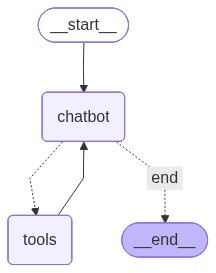

In [12]:

# Display Agent Workflow Graph
# ==============================
from IPython.display import Image, display, Markdown

try:
    # Try to render as PNG image
    graph_image = graph.get_graph().draw_mermaid_png()
    display(Markdown("### Agent Workflow Graph"))
    display(Image(graph_image))
except Exception as e:
    # Fallback to Mermaid text
    display(Markdown("### Agent Workflow Graph (Mermaid)"))
    mermaid_text = graph.get_graph().draw_mermaid()
    display(Markdown(f"```mermaid\n{mermaid_text}\n```"))
    print(f"Note: PNG rendering unavailable. {str(e)}")


In [13]:
def run_agent(query):
    response = graph.invoke({
        "messages": [HumanMessage(content=query)]
    })

    print(response["messages"][-1].content)
    print("\n" + "="*50 + "\n")
    time.sleep(4)

In [ ]:
run_agent("What is sqrt(144) + 25?")

: 

In [ ]:
run_agent("latest AI news")

The latest AI news can be found on Google News, Reuters, and AINews, covering breakthroughs, technology trends, ethical issues, business impact, and more.




In [ ]:
run_agent("linkedin trends in data science")

The LinkedIn trending topics in data science for 2026 highlight the strong influence of AI tools, foundation models, and the expansion of data science roles. Key trends include cutting-edge techniques, tools, and predictions that will reshape the analytics landscape. There's a focus on the ethical implications of AI, as well as the rise of Generative AI as an organizational tool. Staying updated on these trends, essential skills, and the evolving integration of AI and data science into daily life will be crucial for businesses, researchers, and technology leaders.




In [ ]:
# run_agent("What is AAPL stock price?")